In [ ]:
# Repo-root bootstrap — lets this notebook run from notebooks/ or the repo root.
import os, sys
from pathlib import Path
_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "globals.py").exists())
os.chdir(_ROOT)
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
print("repo root:", _ROOT)

# Network debugging — inspect any intermediate output

Interactive scratchpad for looking *inside* the pipelines. Two mechanisms, both defined in the `.py` modules (no heavy code here):

1. **Stage level** — `pipeline.debug = True` makes every forward store the named stage outputs (`bev_camera`, `bev_lidar`, `fused`, `heatmap`, `offset`) in `pipeline.intermediates`; `utils.visualize_pipeline_debug` plots them on the shared BEV grid with the GT centres overlaid.
2. **Any submodule** — `utils.record_activations` hooks arbitrary dotted module paths (backbone, context head, pillar PFN, ...) for one forward pass, without touching the network code.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

import globals as G
import utils
from data import Py123dDataset
from network import LidarOnlyDetector, PipelineA, PipelineB, PipelineC, describe

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

/home/leonardo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


device: cuda


## One frame

In [2]:
dataset = Py123dDataset(split_names=["kitti360_train"], max_num_scenes=1)
frame = dataset.get_frame(0,
                          dataset.scenes[0].number_of_history_iterations + 13)
sample = frame.to_stereo_sample()
print(sample)

StereoSample(dataset='kitti360', log='2013_05_28_drive_0003_sync', iter=13, boxes_3d=3, boxes_2d=2, lidar_pts=120772, depth=no)


## The pipeline classes

One end-to-end trainable class per design pipeline (`network.py`): `PipelineA` (concat+conv fusion), `PipelineB` (A + painted range — raises until the P0 wiring lands; `use_painted_range=False` is the A-control arm), `PipelineC` (cross-attention fusion — stub, TODO P4). `LidarOnlyDetector` is the no-fusion baseline.

In [3]:
pipe = PipelineA().to(DEVICE).eval()
describe(pipe.detector)  # the Stage A contract + parameter counts

with torch.no_grad():
    out = pipe(sample, device=DEVICE)
print({k: tuple(v.shape) for k, v in out.items()})

# The other pipelines are drop-in (both currently raise on their TODO part):
# PipelineB()   -> NotImplementedError (painted-range wiring, P0)
# PipelineC()(sample) -> NotImplementedError (cross-attention fusion, P4)

BEV fusion contract — Stage A must emit, on the shared grid:
  camera BEV : (B, 64, 200, 160)
  lidar  BEV : (B, 128, 200, 160)
  fused      : (B, 128, 200, 160)
  head out   : heatmap (B, 3, 200, 160) + offset (B, 2, 200, 160)
parameters:
  fusion : 369,152
  head   : 74,181
  total  : 443,333
{'heatmap': (1, 3, 200, 160), 'offset': (1, 2, 200, 160)}


## Stage-level debug panel

`pipeline.debug = True` + one forward → `pipeline.intermediates`. The helper plots camera/LiDAR/fused BEV (channel-collapsed), head heatmap and offset magnitude, with in-grid GT centres (cyan rings) for the alignment check. Weights are untrained here — the point is data flow and grid alignment, not detection quality.

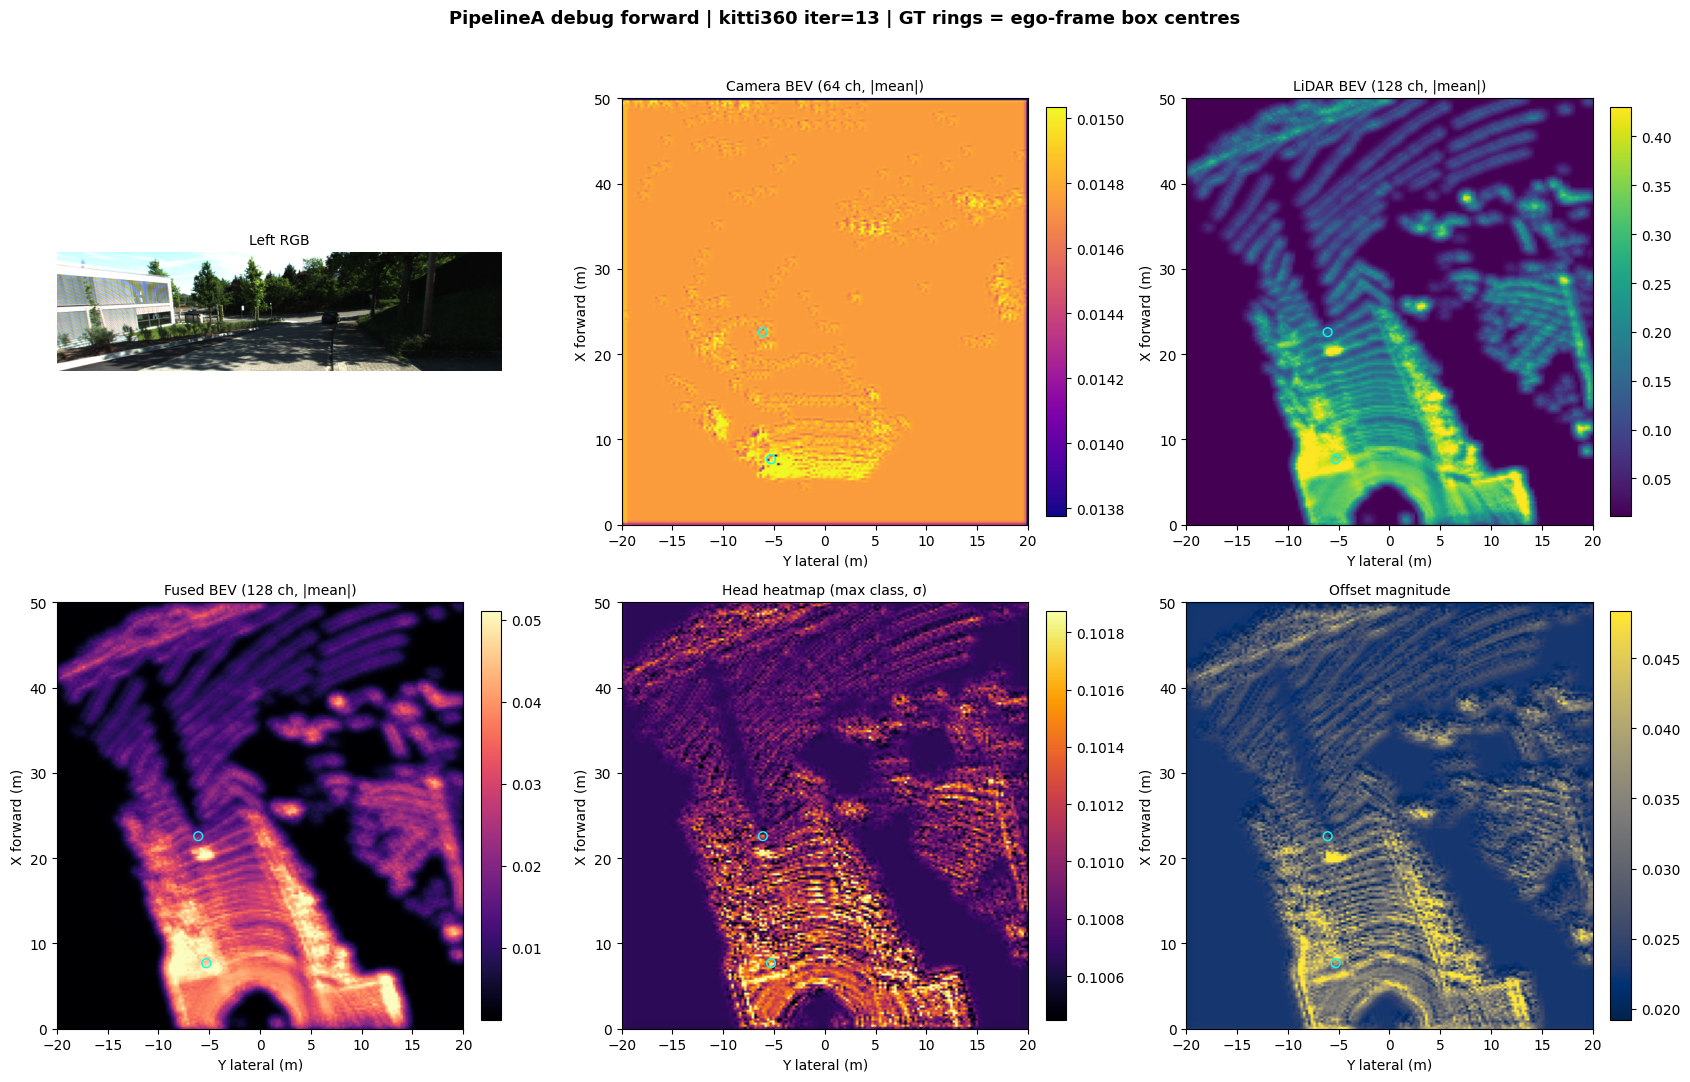

{'bev_camera': (64, 200, 160), 'bev_lidar': (128, 200, 160), 'fused': (128, 200, 160), 'heatmap': (3, 200, 160), 'offset': (2, 200, 160)}


In [4]:
utils.visualize_pipeline_debug(pipe, sample, device=DEVICE)
print({k: tuple(v.shape) for k, v in pipe.intermediates.items()})

## Any submodule: `record_activations`

Hook arbitrary dotted paths for one forward. Discover paths with `dict(pipe.named_modules()).keys()`.

In [5]:
# a few interesting taps (image-space ones are at 1/8 resolution)
layers = [
    "camera_branch.model.backbone",  # shared image features (1, 256, H', W')
    "camera_branch.model.context_head",  # splatted semantics    (1, 64,  H', W')
    "lidar_branch.pfn",  # per-pillar features   (P, 64)
    "detector.fusion",  # fused BEV             (1, 128, nx, ny)
]
with utils.record_activations(pipe, layers) as acts:
    with torch.no_grad():
        pipe(sample, device=DEVICE)
for name, a in acts.items():
    print(f"{name:38s} {tuple(a.shape)}")

lidar_branch.pfn                       (6372, 64)
camera_branch.model.backbone           (1, 256, 24, 80)
camera_branch.model.context_head       (1, 64, 24, 80)
detector.fusion                        (1, 128, 200, 160)


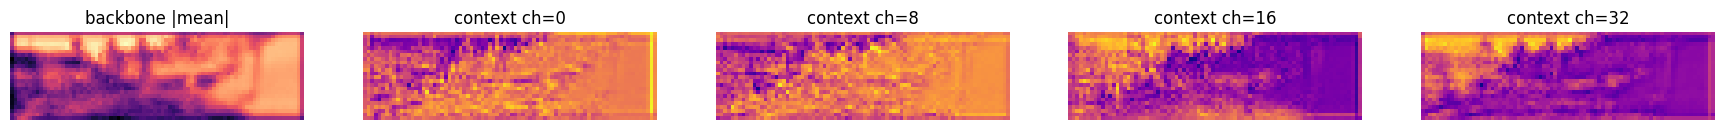

In [6]:
# e.g. image-space maps: backbone |mean| and 4 context-head channels
ctx = acts["camera_branch.model.context_head"][0]  # (64, H', W')
bb = acts["camera_branch.model.backbone"][0]  # (256, H', W')
fig, ax = plt.subplots(1, 5, figsize=(22, 3))
ax[0].imshow(bb.abs().mean(0), cmap="magma")
ax[0].set_title("backbone |mean|")
for i, ch in enumerate((0, 8, 16, 32)):
    ax[1 + i].imshow(ctx[ch], cmap="plasma")
    ax[1 + i].set_title(f"context ch={ch}")
for a in ax:
    a.axis("off")
plt.show()

## After training

The same tools work on a trained pipeline — overfit one frame and re-run the debug panel to watch the heatmap sharpen onto the GT rings. (Headless version: `python tests/test_overfit.py` → `docs/img/overfit_fused_output.png`.)

/home/leonardo/Desktop/AIRO/stereo-lidar-perception/train.py:199: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return total, {"heatmap": float(hm_loss), "offset": float(off_loss)}


loss: 148.04 -> 2.10


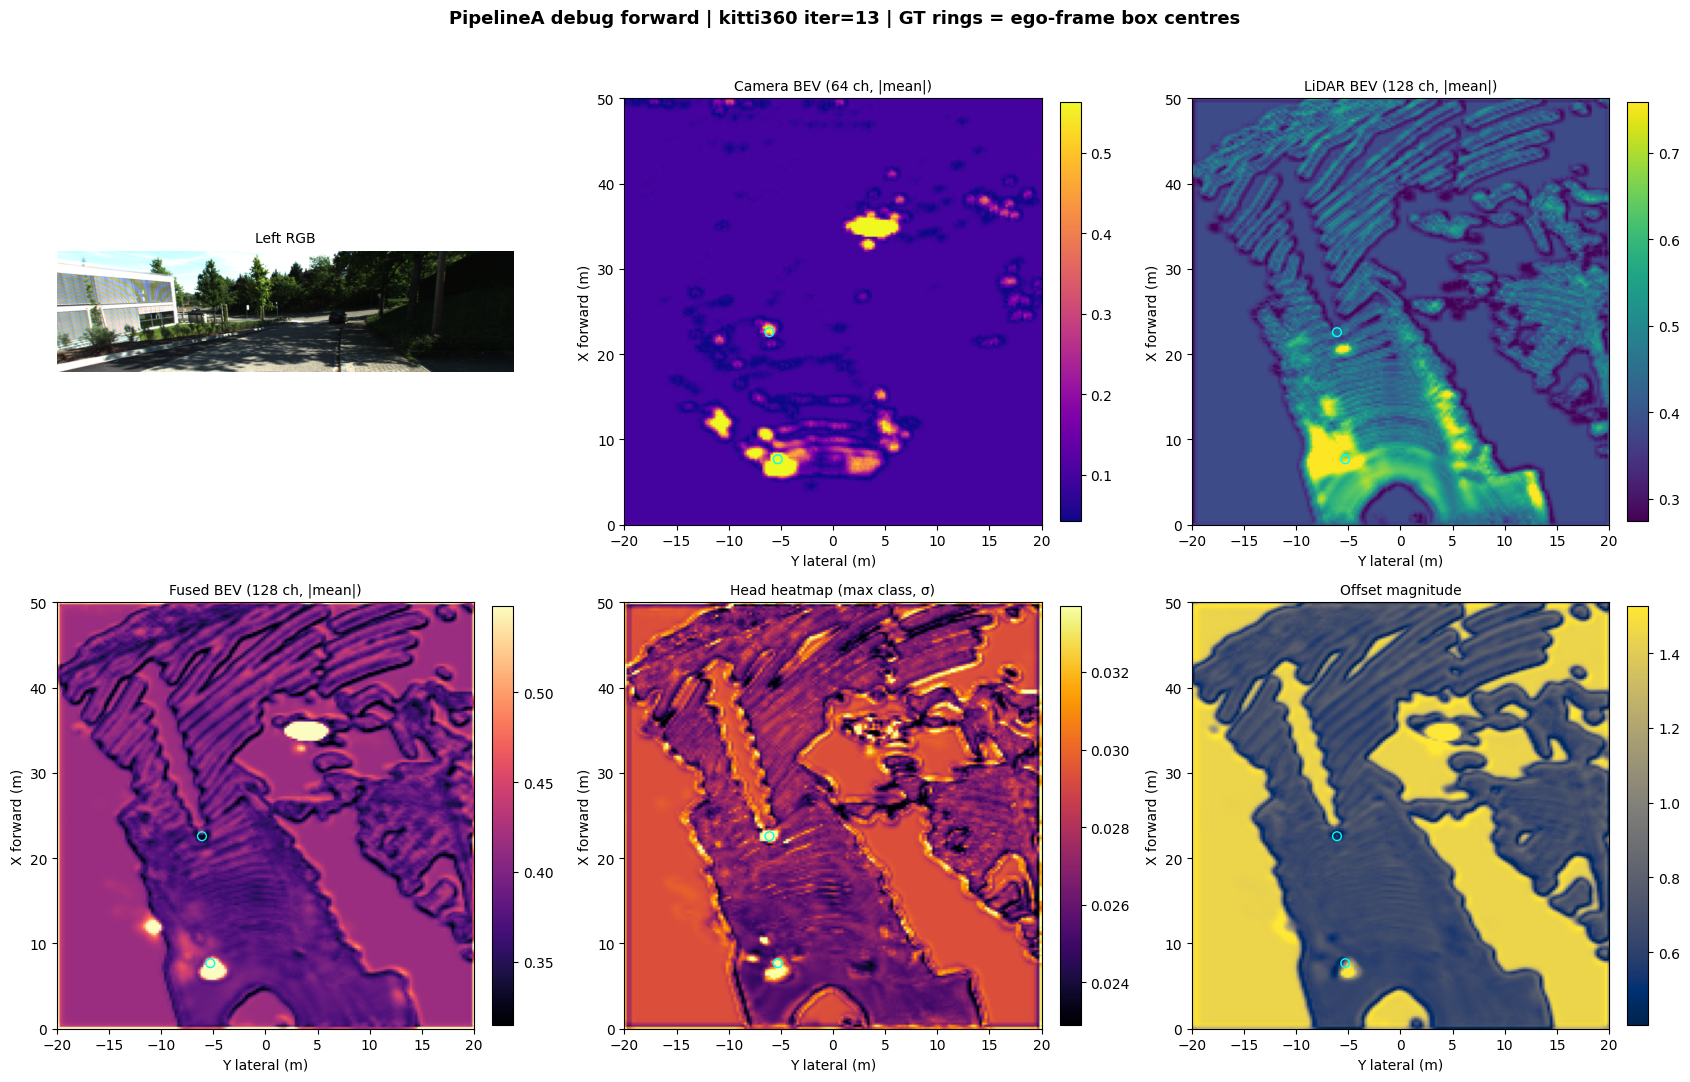

In [7]:
from train import TargetEncoder, encode_sample, overfit_one_frame

tgt_hm, tgt_off = encode_sample(sample, TargetEncoder())
history = overfit_one_frame(pipe,
                            sample,
                            tgt_hm,
                            tgt_off,
                            steps=150,
                            lr=1e-3,
                            device=DEVICE)
print(f"loss: {history[0]:.2f} -> {history[-1]:.2f}")
utils.visualize_pipeline_debug(pipe, sample, device=DEVICE)